<a href="https://colab.research.google.com/github/cdube89128/DATA_620/blob/main/Week3_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 Homework
### DATA 620
### Catherine Dube

**HW Prompt**

This week's assignment is to:

* Load a graph database of your choosing from a text file or other source.  If you take a large network dataset from the web (such as from Stanford Large Network Dataset Collection), please feel free at this point to load just a small subset of the nodes and edges.
* Create basic analysis on the graph, including the graph's diameter, and at least one other metric of your choosing.  You may either code the functions by hand (to build your intuition and insight), or use functions in an existing package.
* Use a visualization tool of your choice (Neo4j, Gephi, etc.) to display information.
* Please record a short video (~ 5 minutes), and submit a link to the video in advance of our meet-up.

**My HW Recap**

* I chose a [Twitch dataset](https://snap.stanford.edu/data/twitch-social-networks.html).
* This is a Twitch user-user network of gamers. Nodes are the users; the edges are mutual friendships between them.
* Of the six language subsets (DE, EN, ES, FR, PT, RU), I'm using **PT** (Portuguese) since it's the smallest, at 1,912 nodes / 31,299 edges.  (This info comes from the source data web page.)
* My basic analysis findings were
 * Graph Diameter (largest component): 7
   * *meaning each of the Poruguese Twitch streamers is within 7 friendships/edges of one another*
 * Average Clustering Coefficient: 0.3199
   * *meaning on average, about 32% of each person's friends are also friends which each other among Portuguese Twitch streamers)*
* Visualization tools were matplotlib and networkX.

# HW Starts Below

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import urllib.request
import zipfile
import os
import glob


### 1: Download and extract the dataset
I updated this with some error checking due to issues when I first tried to download it.

In [ ]:
# Download and Extract the Dataset
url = "https://snap.stanford.edu/data/twitch.zip"
zip_path = "twitch.zip"

# Some servers reject the default urllib user-agent; add a browser-like header
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(req) as resp, open(zip_path, "wb") as out_file:
    out_file.write(resp.read())

print(f"Downloaded {os.path.getsize(zip_path):,} bytes")

# IMPORTANT: verify it's actually a valid zip before trusting the extraction
if not zipfile.is_zipfile(zip_path):
    raise ValueError(
        "Downloaded file is not a valid zip."
    )

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("twitch_data")

print("Extraction complete.")


Downloaded 2,842,994 bytes
Extraction complete.


### 2. Confirming that data
Searching for the right files.

In [ ]:
# 2. Verify the extraction and locate the PT edges file
if not os.path.exists("twitch_data"):
    raise FileNotFoundError("'twitch_data' directory not found -- extraction failed.")

print("Full contents of 'twitch_data':")
for root, dirs, files in os.walk("twitch_data"):
    for f in files:
        print(os.path.join(root, f))

Full contents of 'twitch_data':
twitch_data/twitch/citing.txt
twitch_data/twitch/README.txt
twitch_data/twitch/ENGB/musae_ENGB_features.json
twitch_data/twitch/ENGB/musae_ENGB_target.csv
twitch_data/twitch/ENGB/musae_ENGB_edges.csv
twitch_data/twitch/ES/musae_ES_edges.csv
twitch_data/twitch/ES/musae_ES_features.json
twitch_data/twitch/ES/musae_ES_target.csv
twitch_data/twitch/FR/musae_FR_target.csv
twitch_data/twitch/FR/musae_FR_edges.csv
twitch_data/twitch/FR/musae_FR_features.json
twitch_data/twitch/PTBR/musae_PTBR_features.json
twitch_data/twitch/PTBR/musae_PTBR_target.csv
twitch_data/twitch/PTBR/musae_PTBR_edges.csv
twitch_data/twitch/RU/musae_RU_target.csv
twitch_data/twitch/RU/musae_RU_features.json
twitch_data/twitch/RU/musae_RU_edges.csv
twitch_data/twitch/DE/musae_DE_target.csv
twitch_data/twitch/DE/musae_DE.json
twitch_data/twitch/DE/musae_DE_edges.csv


In [ ]:
# The PTBR edges file, found it after running the above code block
edges_path = "twitch_data/twitch/PTBR/musae_PTBR_edges.csv"

if not os.path.exists(edges_path):
    raise FileNotFoundError(
        f"Expected file not found at {edges_path}. "
        "Re-run the extraction step or re-check the directory tree."
    )

print(f"Using edges file: {edges_path}")

Using edges file: twitch_data/twitch/PTBR/musae_PTBR_edges.csv


### 3: Load the graph

In [ ]:
# Load the Graph Database
edges_df = pd.read_csv(edges_path)
print(edges_df.head())

# Create a NetworkX graph from the edgelist
G = nx.from_pandas_edgelist(edges_df, source=edges_df.columns[0], target=edges_df.columns[1])

print(f"\nGraph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


   from    to
0     0    92
1     0   428
2     1   689
3     1  1147
4     1  1666

Graph loaded: 1912 nodes, 31299 edges


### 4: Basic network analysis

In [ ]:
# Basic Analysis
print(f"Is the full graph connected? {nx.is_connected(G)}")
print(f"Number of connected components: {nx.number_connected_components(G)}")

largest_cc = max(nx.connected_components(G), key=len)
G_core = G.subgraph(largest_cc).copy()
print(f"Largest component: {G_core.number_of_nodes()} nodes "
      f"({G_core.number_of_nodes() / G.number_of_nodes():.1%} of all nodes)")

diameter = nx.diameter(G_core)
avg_clustering = nx.average_clustering(G_core)

print(f"\nGraph Diameter (largest component): {diameter}")
print(f"Average Clustering Coefficient: {avg_clustering:.4f}")


Is the full graph connected? True
Number of connected components: 1
Largest component: 1912 nodes (100.0% of all nodes)

Graph Diameter (largest component): 7
Average Clustering Coefficient: 0.3199


#### For Funsies Exploratory Analysis

In [ ]:
# Some more Exploratory Analysis
target_path = "twitch_data/twitch/PTBR/musae_PTBR_target.csv"
target_df = pd.read_csv(target_path)

print("Columns available:", list(target_df.columns))
print(target_df.head())
print(f"\nTotal streamers in target file: {len(target_df)}")

# Degree = number of connections (friends) each node (streamer) has
degrees = dict(G.degree())
degree_series = pd.Series(degrees)

print(f"\nAverage connections per streamer: {degree_series.mean():.2f}")
print(f"Median connections per streamer: {degree_series.median():.0f}")
print(f"Max connections (most-followed streamer): {degree_series.max()}")
print(f"Min connections: {degree_series.min()}")

Columns available: ['id', 'days', 'mature', 'views', 'partner', 'new_id']
          id  days  mature   views  partner  new_id
0   44891403  1943   False  929459     True    1706
1   61180621  1633   False   11194    False    1273
2  145109685   632   False    2850    False     313
3  122121521   906    True    3422    False    1570
4  189445819   267   False      71    False     800

Total streamers in target file: 1912

Average connections per streamer: 32.74
Median connections per streamer: 17
Max connections (most-followed streamer): 767
Min connections: 1


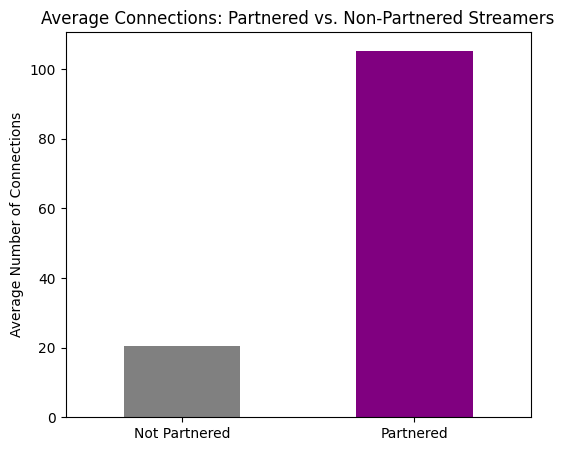

Not Partnered     20.336803
Partnered        105.333333
Name: connections, dtype: float64


In [ ]:
# Average connections by partner status
partner_avg = target_df.groupby("partner")["connections"].mean()
partner_avg.index = ["Not Partnered", "Partnered"]

partner_avg.plot(kind="bar", color=["gray", "purple"], figsize=(6, 5))
plt.title("Average Connections: Partnered vs. Non-Partnered Streamers")
plt.ylabel("Average Number of Connections")
plt.xticks(rotation=0)
plt.show()

print(partner_avg)

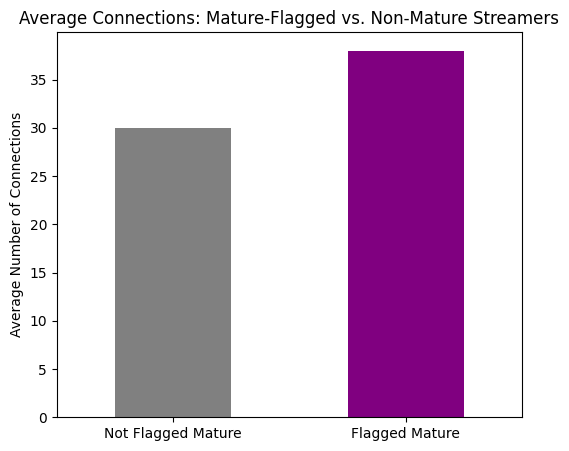

Not Flagged Mature    29.956835
Flagged Mature        38.006051
Name: connections, dtype: float64


In [ ]:
# Average connections by mature-content flag
mature_avg = target_df.groupby("mature")["connections"].mean()
mature_avg.index = ["Not Flagged Mature", "Flagged Mature"]

mature_avg.plot(kind="bar", color=["gray", "purple"], figsize=(6, 5))
plt.title("Average Connections: Mature-Flagged vs. Non-Mature Streamers")
plt.ylabel("Average Number of Connections")
plt.xticks(rotation=0)
plt.show()

print(mature_avg)

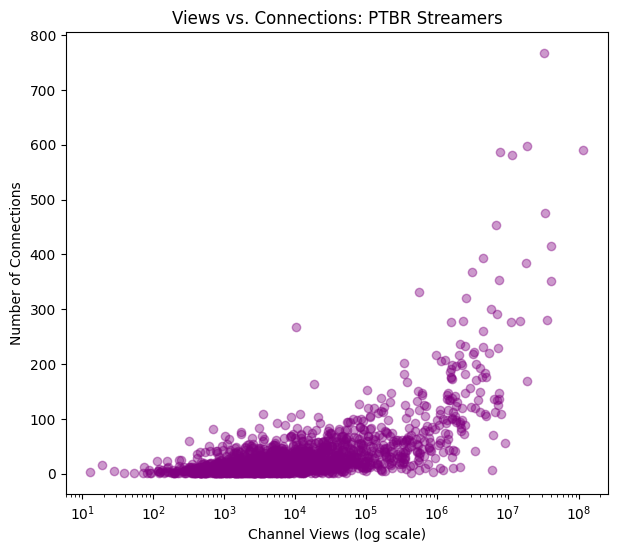

Correlation (views, connections): 0.591


In [ ]:
# Views vs. connections -- do bigger channels have more mutual friends, or fewer?
plt.figure(figsize=(7, 6))
plt.scatter(target_df["views"], target_df["connections"], alpha=0.4, color="purple")
plt.xscale("log")
plt.xlabel("Channel Views (log scale)")
plt.ylabel("Number of Connections")
plt.title("Views vs. Connections: PTBR Streamers")
plt.show()

print(f"Correlation (views, connections): {target_df['views'].corr(target_df['connections']):.3f}")

### 5: Visualization

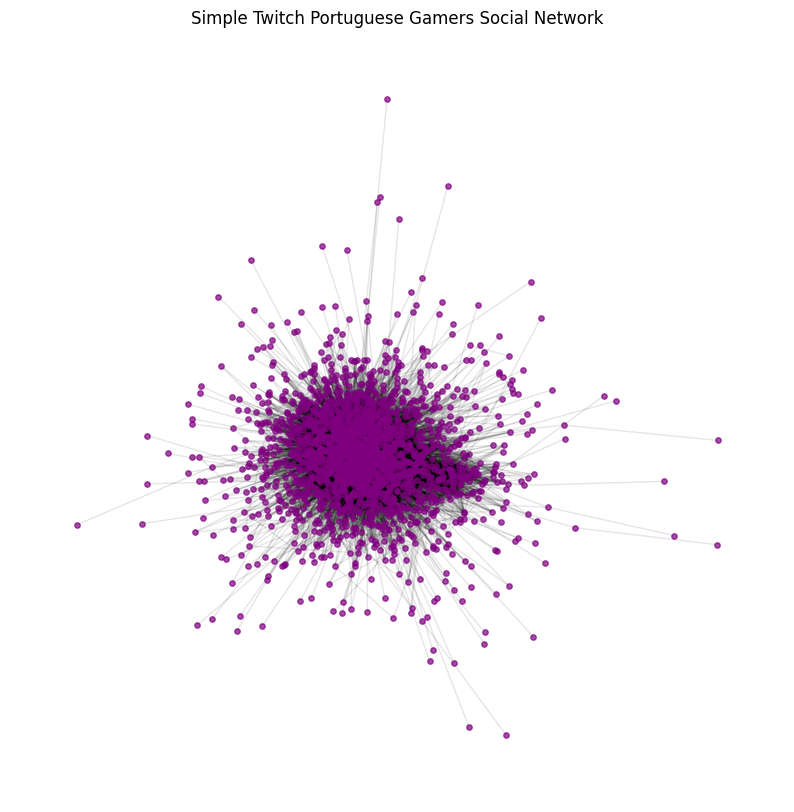

In [ ]:
# Visualization
plt.figure(figsize=(10, 10))
plt.title("Simple Twitch Portuguese Gamers Social Network")

pos = nx.spring_layout(G_core, seed=42)
nx.draw_networkx_nodes(G_core, pos, node_size=15, node_color='purple', alpha=0.7)
nx.draw_networkx_edges(G_core, pos, alpha=0.1)

plt.axis('off')
plt.show()


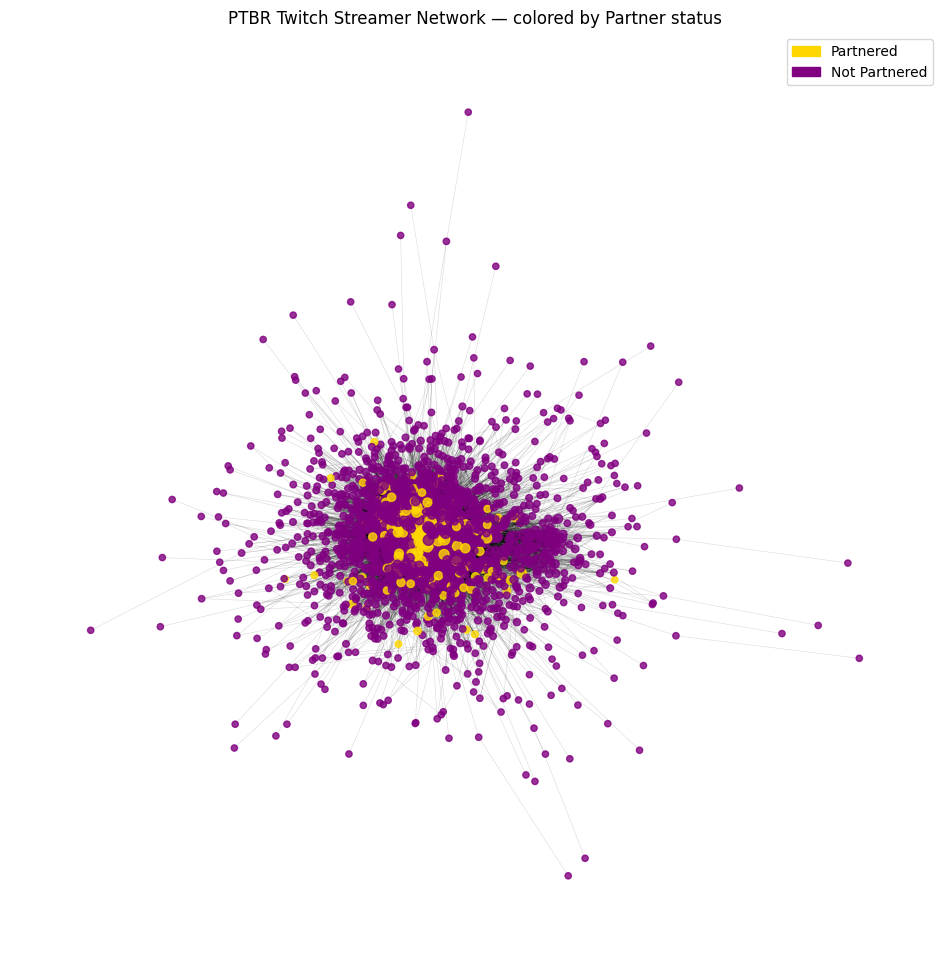

In [ ]:
# Updated network visualization: color by partner status, sized by degree
plt.figure(figsize=(12, 12))
plt.title("PTBR Twitch Streamer Network — colored by Partner status")

# Tighter layout than before (lower k = nodes pulled closer together)
pos = nx.spring_layout(G_core, seed=42, k=0.15, iterations=50)

# Map partner status onto colors, in the same node order as G_core
partner_lookup = target_df.set_index("node_id")["partner"]
node_colors = ["gold" if partner_lookup.get(n, False) else "purple" for n in G_core.nodes()]

# Size nodes by degree so hubs visually stand out
node_sizes = [20 + degrees[n] * 0.5 for n in G_core.nodes()]

nx.draw_networkx_nodes(G_core, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G_core, pos, alpha=0.15, width=0.4)

# Simple legend since we're not using nx's built-in one
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color="gold", label="Partnered"),
    mpatches.Patch(color="purple", label="Not Partnered"),
]
plt.legend(handles=legend_handles, loc="upper right")

plt.axis('off')
plt.show()